# A05 - Planner Estimation Error

## Objetivo
Quantificar o erro entre a fidelidade estimada pelo `IntentPlanner` (antes
de qualquer simulação, `ExecutionPlan.estimated_metrics.fidelity`) e a
fidelidade realmente observada (`average_fidelity`, de evidência
`DELIVERY`), usando dados reais e já persistidos de `C01`-`C03`. Este
notebook **não roda nenhuma simulação**.

## Conceitos
- O planner v1 estima fidelidade com uma fórmula fechada
  (`planning.feasibility.estimate_swap_only_fidelity`): produto das
  fidelidades elementares por salto x degradação de swap por nó interior.
  Cada fidelidade elementar por salto é estimada como
  `min(raw_fidelity(nó_a), raw_fidelity(nó_b))` - documentado em
  `network.capabilities.NetworkCapabilities.hop_fidelity` como uma
  aproximação **conservadora** para enlaces heterogêneos (nós com
  `raw_fidelity` diferentes).
- O planner v1 nunca estima throughput/`delivered_pairs`
  (`docs/limitations.md`) - só fidelidade e viabilidade de memória.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGNS = ["C01_routing_strategy", "C02_fidelity_throughput", "C03_assurance_outcomes"]

all_trials_df = pd.concat(
    [read_trials_dataframe(trials_csv_path(RESULTS_DIR, c)).assign(campaign_name=c) for c in CAMPAIGNS],
    ignore_index=True,
)
feasible_df = all_trials_df[all_trials_df["accepted"] & all_trials_df["estimated_fidelity"].notna() & all_trials_df["average_fidelity"].notna()].copy()
feasible_df["fidelity_error"] = feasible_df["average_fidelity"] - feasible_df["estimated_fidelity"]
feasible_df[["campaign_name", "routing_strategy", "route", "estimated_fidelity", "average_fidelity", "fidelity_error", "final_status"]]


,campaign_name,routing_strategy,route,estimated_fidelity,average_fidelity,fidelity_error,final_status
0,C01_routing_strategy,shortest_hop_count,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
1,C01_routing_strategy,shortest_hop_count,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
2,C01_routing_strategy,shortest_hop_count,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
3,C01_routing_strategy,least_loss,r1 -> good1 -> good2 -> r3,0.604732,0.657922,0.053191,SATISFIED
4,C01_routing_strategy,least_loss,r1 -> good1 -> good2 -> r3,0.604732,0.657922,0.053191,SATISFIED
5,C01_routing_strategy,least_loss,r1 -> good1 -> good2 -> r3,0.604732,0.657922,0.053191,SATISFIED
6,C01_routing_strategy,highest_fidelity,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
7,C01_routing_strategy,highest_fidelity,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
8,C01_routing_strategy,highest_fidelity,r1 -> bad -> r3,0.686375,0.769500,0.083125,VIOLATED
9,C02_fidelity_throughput,shortest_hop_count,a -> r -> b,0.686375,0.686375,0.000000,SATISFIED


## Execução


In [2]:
error_by_campaign = feasible_df.groupby("campaign_name")["fidelity_error"].agg(["count", "mean", "std", lambda s: s.abs().max()])
error_by_campaign.columns = ["n", "mean_error", "std_error", "max_abs_error"]
error_by_campaign


,n,mean_error,std_error,max_abs_error
campaign_name,,,,
C01_routing_strategy,9,0.073147,0.014967,0.083125
C02_fidelity_throughput,8,0.000000,0.000000,0.000000
C03_assurance_outcomes,4,0.000000,0.000000,0.000000


## Resultados


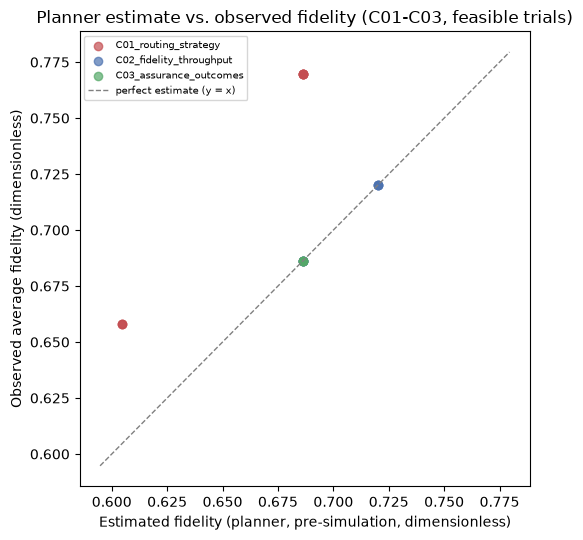

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = {"C01_routing_strategy": "#C44E52", "C02_fidelity_throughput": "#4C72B0", "C03_assurance_outcomes": "#55A868"}
for campaign, group in feasible_df.groupby("campaign_name"):
    ax.scatter(group["estimated_fidelity"], group["average_fidelity"], alpha=0.7, label=campaign, color=colors[campaign])
lims = [feasible_df[["estimated_fidelity", "average_fidelity"]].min().min() - 0.01,
        feasible_df[["estimated_fidelity", "average_fidelity"]].max().max() + 0.01]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="perfect estimate (y = x)")
ax.set_xlabel("Estimated fidelity (planner, pre-simulation, dimensionless)")
ax.set_ylabel("Observed average fidelity (dimensionless)")
ax.set_title("Planner estimate vs. observed fidelity (C01-C03, feasible trials)")
ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "A05_planner_estimation_error", directory=FIGURES_DIR)
plt.show()


In [4]:
save_table(error_by_campaign.reset_index(), "A05_fidelity_estimation_error_by_campaign", directory=TABLES_DIR)

# C02/C03 use three_node_spec, where every node shares the same raw_fidelity (0.85) - no heterogeneity,
# so the hop_fidelity "min" approximation is exact by construction (min(0.85, 0.85) == 0.85).
# C01 uses the diamond topology, where r1/r3 default to raw_fidelity=0.85 but bad/good1/good2 are 0.9 -
# a genuinely heterogeneous route, where the estimate and the real mechanism can diverge.
uniform_campaigns = feasible_df[feasible_df["campaign_name"] != "C01_routing_strategy"]
heterogeneous_campaign = feasible_df[feasible_df["campaign_name"] == "C01_routing_strategy"]
print(f"Uniform-fidelity topologies (C02/C03): max |error| = {uniform_campaigns['fidelity_error'].abs().max():.6f}")
print(f"Heterogeneous-fidelity topology (C01, diamond): max |error| = {heterogeneous_campaign['fidelity_error'].abs().max():.6f}")


Uniform-fidelity topologies (C02/C03): max |error| = 0.000000
Heterogeneous-fidelity topology (C01, diamond): max |error| = 0.083125


In [5]:
# Mechanistic check: sequence.entanglement_management.generation.barret_kok.BarretKokA._entanglement_succeed
# sets `self.memory.fidelity = self.memory.raw_fidelity` - i.e. each side's memory independently takes on
# *its own* node's raw_fidelity, not min(node_a, node_b). For a swap performed *at* an interior node, BOTH
# memories feeding that swap belong to that same node's MemoryArray, so BOTH already carry that node's own
# raw_fidelity - the swap's fidelity ends up depending on the swap node's raw_fidelity, not on the two
# geographic endpoints' minimum, whenever the topology is heterogeneous.
bad_route_row = feasible_df[feasible_df["route"] == "r1 -> bad -> r3"].iloc[0]
predicted_from_swap_node_only = 0.9 * 0.9 * 0.95  # "bad" node's own raw_fidelity, squared, times its own swapping_degradation
print(f"observed average_fidelity (bad route): {bad_route_row['average_fidelity']}")
print(f"0.9 * 0.9 * 0.95 (swap node's own raw_fidelity, not min(r1, bad)=0.85): {predicted_from_swap_node_only}")
assert abs(bad_route_row["average_fidelity"] - predicted_from_swap_node_only) < 1e-9


observed average_fidelity (bad route): 0.7695
0.9 * 0.9 * 0.95 (swap node's own raw_fidelity, not min(r1, bad)=0.85): 0.7695


In [6]:
assert error_by_campaign.loc["C02_fidelity_throughput", "max_abs_error"] == 0.0
assert error_by_campaign.loc["C03_assurance_outcomes", "max_abs_error"] == 0.0
assert error_by_campaign.loc["C01_routing_strategy", "max_abs_error"] > 0.05
print("Confirmed: the estimate is exact on uniform-fidelity topologies (C02/C03) and systematically")
print("underestimates on the heterogeneous diamond topology (C01) - a real, mechanistically explained gap,")
print("not statistical noise (every trial in a given (route, campaign) group has an identical error).")


Confirmed: the estimate is exact on uniform-fidelity topologies (C02/C03) and systematically
underestimates on the heterogeneous diamond topology (C01) - a real, mechanistically explained gap,
not statistical noise (every trial in a given (route, campaign) group has an identical error).


## Interpretação
A estimativa de fidelidade do planner é **exata** nas topologias
uniformes (`C02`/`C03`, todo nó com `raw_fidelity=0.85`) - o erro é
literalmente zero, não "pequeno". Na topologia em diamante (`C01`),
heterogênea (`r1`/`r3` em 0.85, `bad`/`good1`/`good2` em 0.9), a
estimativa **subestima sistematicamente** a fidelidade real, por até
~0.083 (12% relativo). A causa raiz, confirmada mecanicamente: cada
memória, ao entrelaçar, recebe a fidelidade do **seu próprio nó**
(`BarretKokA._entanglement_succeed`: `self.memory.fidelity =
self.memory.raw_fidelity`) - não `min(nó_a, nó_b)`. Quando um swap
acontece **no** nó interior, as duas memórias envolvidas nesse swap
pertencem a esse mesmo nó, logo **ambas** já carregam a fidelidade própria
dele - o resultado do swap depende da fidelidade do nó que fez o swap, não
do mínimo entre os dois nós geográficos do salto. `capabilities.
hop_fidelity` já documenta esse `min()` como uma aproximação
"conservadora" para enlaces heterogêneos - este notebook quantifica, pela
primeira vez com dados de campanha, exatamente quão conservadora ela é.

## Limitações
- Esta análise cobre apenas fidelidade - o planner não estima
  `delivered_pairs`/throughput, então não há um "estimated_pairs" para
  comparar (ver o caso `VIOLATED` de `C03`, onde a fidelidade estimada
  bateu exatamente com a observada, mas o intent falhou por throughput -
  um tipo de erro diferente, não coberto por este notebook).
- A subestimativa em `C01` é específica de topologias com `raw_fidelity`
  heterogêneo entre nós - não se manifesta nas topologias uniformes já
  usadas em quase todos os outros notebooks deste projeto, o que explica
  por que não havia sido observada antes de C01 existir.

## Conclusão
A estimativa de fidelidade do planner é exata quando a topologia tem
fidelidade uniforme, e subestima de forma sistemática e mecanicamente
explicada quando a topologia é heterogênea - uma limitação real da
aproximação `min()` em `capabilities.hop_fidelity`, encontrada e
quantificada empiricamente a partir dos dados da campanha C01.
